In [1]:
import importlib
import torch
import NeuralNetwork, funcs, funcs_for_letters as ffl, setup

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
importlib.reload(ffl)
importlib.reload(setup)

device = setup.get_device()
print(f"Device: {device}")

device being used: cuda
Device: cuda


## Load pruned digit model

In [2]:
pruned_model = torch.load("pruned_model.pth", weights_only=False, map_location=device)
pruned_model.eval()

cluster_map   = getattr(pruned_model, "final_cluster_map",   None)
layer_mapping = getattr(pruned_model, "final_layer_mapping", None)

print(f"Architecture : {ffl._arch_str(pruned_model)}")
print(f"Clusters     : {len(cluster_map) if cluster_map else 0}")
print(f"Align score  : {getattr(pruned_model, "final_alignment_score", "n/a")}")

Architecture : 784 → 36 → 26 → 21 → 17 → 10
Clusters     : 8
Align score  : 0.00047038542358092406


In [ ]:
# ── Load pre-trained letter models (run this INSTEAD of Cells 6-8 if already saved) ──
m_transfer = torch.load("m_transfer.pth", weights_only=False, map_location=device)
m_reset    = torch.load("m_reset.pth",    weights_only=False, map_location=device)
m_fc       = torch.load("m_fc.pth",       weights_only=False, map_location=device)
for m in [m_transfer, m_reset, m_fc]:
    m.eval()
print("Letter models loaded.")

## Load EMNIST letters data

In [3]:
# EMNIST letters: 26 classes (A-Z), ~112k train / ~18k test
train_loader, val_loader, test_loader = ffl.get_letters_dataloaders(batch_size=8000)

Letters (lowercase only) — train: 147546, val: 16393, test: 27059


## Build three models

| Model | Description |
|---|---|
| **transfer** | Digit hidden layers frozen, layer-0 reset, new output head |
| **reset** | Same sparse topology, all weights re-initialised |
| **fc_baseline** | Fully-connected MLP with same neuron counts |


In [4]:
# --- Model 1: Transfer ---
# unfreeze_clusters: list of cluster IDs to allow training (None = all frozen)
# ignore_clusters  : list of cluster IDs to permanently silence
m_transfer = ffl.build_transfer_model(
    pruned_model,
    n_letters=26,
    unfreeze_clusters=None,   # e.g. [5] to let the catch-all cluster adapt
    ignore_clusters=None,     # e.g. [8] to silence a dead cluster
)

# --- Model 2: Reset (same sparsity, random weights) ---
m_reset = ffl.build_reset_model(pruned_model, n_letters=26)

# --- Model 3: Fully-connected benchmark ---
m_fc = ffl.build_fc_benchmark(pruned_model, n_letters=26)

Transfer model built: 784 → 36 → 26 → 21 → 17 → 26
  Trainable params : 28728
Reset model built: 784 → 36 → 26 → 21 → 17 → 26
FC benchmark built: 784 → 36 → 26 → 21 → 17 → 26


## Train

In [5]:
N_EPOCHS = 20

for name, m in [("transfer", m_transfer), ("reset", m_reset), ("fc_baseline", m_fc)]:
    print(f"=== Training {name} ===")
    m.optimizer = None   # reset so Adam is re-created with correct param set
    m.train_model(train_loader, epochs=N_EPOCHS, lr=1e-3, val_split=0)

=== Training transfer ===


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 2/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 3/20:   0%|          | 0/19 [00:00<?, ?batches/s]

...

Epoch 16/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 17/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 18/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 19/20:   0%|          | 0/19 [00:00<?, ?batches/s]

Epoch 20/20:   0%|          | 0/19 [00:00<?, ?batches/s]

In [ ]:
torch.save(m_transfer, "m_transfer.pth")
torch.save(m_reset,    "m_reset.pth")
torch.save(m_fc,       "m_fc.pth")
print("Letter models saved.")

## Compare results

In [6]:
results = ffl.compare_models(
    {"transfer": m_transfer, "reset": m_reset, "fc_baseline": m_fc},
    test_loader
)


Model                 Test Acc     Params   Connections
-------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

transfer                0.8175     30,631        28,768


  0%|          | 0/4 [00:00<?, ?it/s]

reset                   0.5928     30,631        28,768


  0%|          | 0/4 [00:00<?, ?it/s]

fc_baseline             0.8160     30,631        30,505


## (Optional) Transfer with selective cluster unfreezing

Unfreeze specific clusters to let them adapt to letters while keeping
the rest of the network frozen. Useful for testing whether the
catch-all cluster (C5) or other clusters need to re-specialise.


In [7]:
# Uncomment to run
# importlib.reload(ffl)
# m_partial = ffl.build_transfer_model(
#     pruned_model,
#     n_letters=26,
#     unfreeze_clusters=[5],   # let C5 (catch-all) adapt
#     ignore_clusters=[8],     # silence dead C8
# )
# m_partial.optimizer = None
# m_partial.train_model(train_loader, epochs=N_EPOCHS, lr=1e-3, val_split=0)
# print(f"Partial unfreeze test acc: {m_partial.accuracy(test_loader):.4f}")

## Sanity check layer freeze status

In [8]:
def freeze_report(m, name):
    lin_idx = [i for i, l in enumerate(m.layer_stack) if isinstance(l, torch.nn.Linear)]
    print(f"{name}:")
    for k, i in enumerate(lin_idx):
        print(f"  layer_{k} (stack[{i}]) requires_grad={m.layer_stack[i].weight.requires_grad}")

freeze_report(m_transfer,  "transfer")
freeze_report(m_reset,     "reset")
freeze_report(m_fc,        "fc_baseline")


transfer:
  layer_0 (stack[0]) requires_grad=True
  layer_1 (stack[2]) requires_grad=False
  layer_2 (stack[4]) requires_grad=False
  layer_3 (stack[6]) requires_grad=False
  layer_4 (stack[8]) requires_grad=True
reset:
  layer_0 (stack[0]) requires_grad=True
  layer_1 (stack[2]) requires_grad=True
  layer_2 (stack[4]) requires_grad=True
  layer_3 (stack[6]) requires_grad=True
  layer_4 (stack[8]) requires_grad=True
fc_baseline:
  layer_0 (stack[0]) requires_grad=True
  layer_1 (stack[2]) requires_grad=True
  layer_2 (stack[4]) requires_grad=True
  layer_3 (stack[6]) requires_grad=True
  layer_4 (stack[8]) requires_grad=True


In [9]:
import analysis

letter_names = [chr(ord('a') + i) for i in range(26)]

ablation_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    ablation_results[cluster_id] = analysis.cluster_criticality_per_class(
        m_transfer, neuron_indices, layer_mapping, val_loader, cluster_id, device=device
    )
    pre  = ablation_results[cluster_id]['pre']
    post = ablation_results[cluster_id]['post']
    drops = {letter_names[c]: round(pre[c] - post[c], 3) for c in sorted(pre)}
    print(f"  Ablation drops: { {k: v for k, v in drops.items() if v > 0.05} }")



--- Calculating pre and post-ablation accuracy for cluster 5 ---


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  Ablation drops: {'a': 0.85, 'e': 0.117, 'f': 0.485, 'g': 0.532, 'j': 0.058, 'm': 0.854, 'n': 0.849, 'o': 0.182, 'p': 0.444, 'q': 0.422, 's': 0.754, 'u': 0.146, 'x': 0.283, 'y': 0.383, 'z': 0.166}

--- Calculating pre and post-ablation accuracy for cluster 4 ---


  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  Ablation drops: {'f': 0.149, 'x': 0.141}

--- Calculating pre and post-ablation accuracy for cluster 8 ---


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  Ablation drops: {'b': 0.247, 'c': 0.572, 'd': 0.784, 'f': 0.072, 'g': 0.262, 'i': 0.117, 'j': 0.347, 'k': 0.246, 's': 0.365, 'u': 0.078, 'v': 0.148, 'x': 0.371, 'z': 0.514}


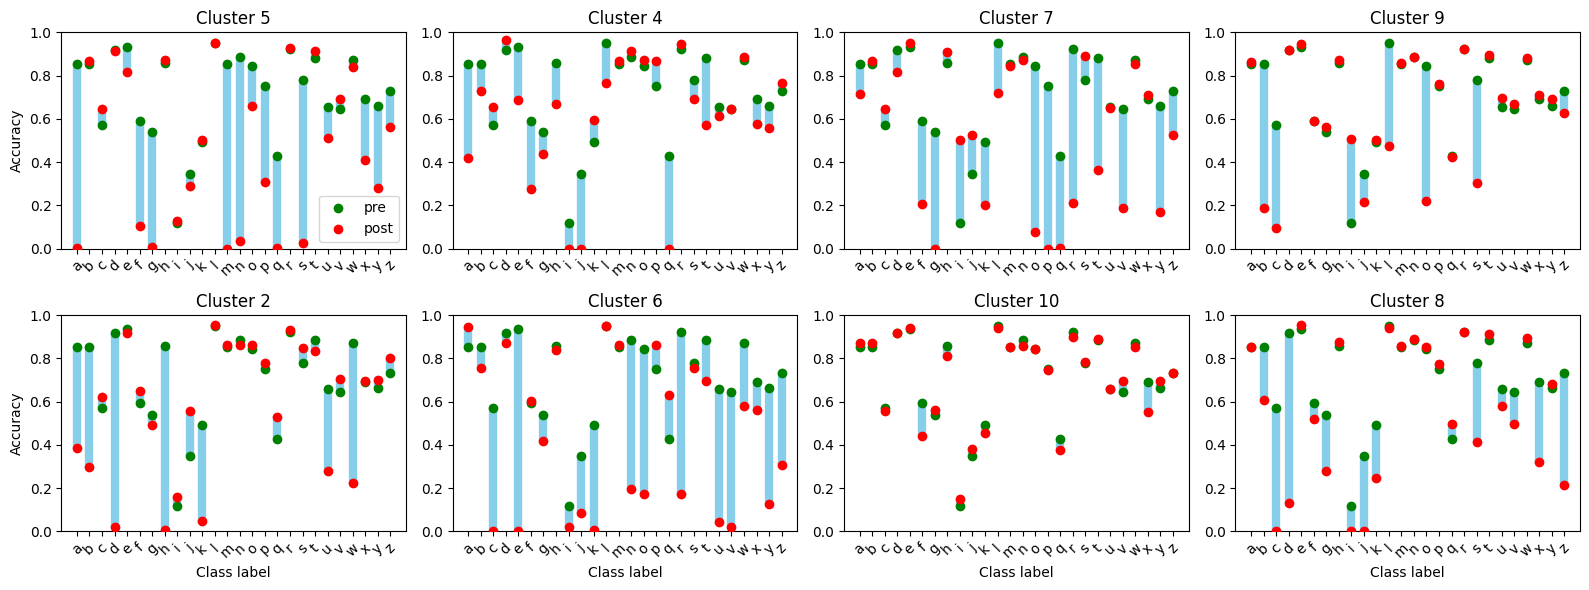

In [10]:
import plots
letter_ablation = {
    cid: {
        'pre':  {letter_names[c]: v for c, v in result['pre'].items()},
        'post': {letter_names[c]: v for c, v in result['post'].items()}
    }
    for cid, result in ablation_results.items()
}
plots.plot_cluster_accuracy_bars(letter_ablation, target_labels=letter_names)


In [ ]:
importlib.reload(ffl)
importlib.reload(funcs)

# Quick smoke-test: set n_seeds=1, n_epochs_half=3
# For the real run: n_seeds=5, n_epochs_half=50
results = ffl.run_experiment(
    pruned_model,
    n_seeds       = 3,
    n_epochs_half = 10,
    lr            = 1e-3,
    batch_size    = 4096,
    threshold_frac= 1.5,
    n_spawn       = 5,
    device        = device,
)

Letters (lowercase only) — train: 147546, val: 16393, test: 27059

SEED 0
Transfer model built: 784 → 36 → 26 → 21 → 17 → 26
  Trainable params : 28728
Transfer model built: 784 → 36 → 26 → 21 → 17 → 26
  Trainable params : 28728
Transfer model built: 784 → 36 → 26 → 21 → 17 → 26
  Trainable params : 28728
FC benchmark built: 784 → 36 → 26 → 21 → 17 → 26
Random-frozen model: 784 → 36 → 26 → 21 → 17 → 26  (emp_std=0.2646)
Random-frozen model: 784 → 36 → 26 → 21 → 17 → 26  (emp_std=0.2646)

-- Half 1 --

  [frozen_transfer]
    frozen_transfer h1 ep 1/10  val=0.7797
    frozen_transfer h1 ep 2/10  val=0.8288
    frozen_transfer h1 ep 3/10  val=0.8451
    frozen_transfer h1 ep 4/10  val=0.8505
    frozen_transfer h1 ep 5/10  val=0.8633
    frozen_transfer h1 ep 6/10  val=0.8677
    frozen_transfer h1 ep 7/10  val=0.8693
    frozen_transfer h1 ep 8/10  val=0.8731
    frozen_transfer h1 ep 9/10  val=0.8732
    frozen_transfer h1 ep 10/10  val=0.8778

  [frozen_regrowth]
    frozen_regrowth 

In [ ]:
ffl.save_results(results, pruned_model)
print("Results saved to results/")

In [ ]:
import importlib
import setup, analysis
importlib.reload(ffl)
importlib.reload(analysis)

_, digit_val_loader, _ = setup.get_dataloaders(batch_size=4000)

digit_ablation = {}
for cluster_id, neuron_indices in cluster_map.items():
    digit_ablation[cluster_id] = analysis.cluster_criticality_per_class(
        pruned_model, neuron_indices, layer_mapping, digit_val_loader, cluster_id, device=device)

ffl.plot_cluster_ablation_grid(
    letter_ablation=letter_ablation,
    digit_ablation=digit_ablation,
    m_transfer=m_transfer,
    pruned_model=pruned_model,
    cluster_map=cluster_map,
    layer_mapping=layer_mapping,
    letter_loader=val_loader,
    digit_loader=digit_val_loader,
    threshold=0.05,
    n_samples=20,
    pixel_threshold=0.3,
    device=device
)